# 04 — Custo, Latência e Eficiência (só ferramenta)

**Pergunta principal:** *quanto cada modelo cobra, demora, e onde vai esse tempo?*

> Este notebook usa **apenas** as linhas de `origem_resultado == 'ferramenta'`. O chat web (`std_chatgpt`, `std_claude`) não expõe `latencia_s`, `custo_estimado_usd` nem `n_invocacoes`, então fica de fora.


In [1]:
import sys
sys.path.insert(0, '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from utils import (
    carregar_dados, estilo_padrao,
    ORDEM_MODELOS, CORES_FAMILIA, FAMILIA, MODELO_DISPLAY,
    titulo_acima, rotulos_em_cima,
)

estilo_padrao()
df = carregar_dados()

fer = df[df['origem_resultado'] == 'ferramenta'].copy()
ordem_fer = [m for m in ORDEM_MODELOS if '(chat web)' not in m]
print(f'Linhas (só ferramenta): {len(fer)}')
print(f'Modelos: {fer["modelo_display"].nunique()}')

Linhas (só ferramenta): 1350
Modelos: 9


## 1. A distinção que o estudo v1 não deixava clara

O campo `output_tokens` é o **fluxo interno todo** do modelo — inclui raciocínio (pensamentos não exibidos), chamadas de ferramenta e a resposta final. O usuário só vê o último pedaço, contado em `resposta_tokens_tiktoken`.

A diferença `output_tokens − resposta_tokens_tiktoken` é o overhead invisível: quanto o modelo "pensou" para produzir a resposta.


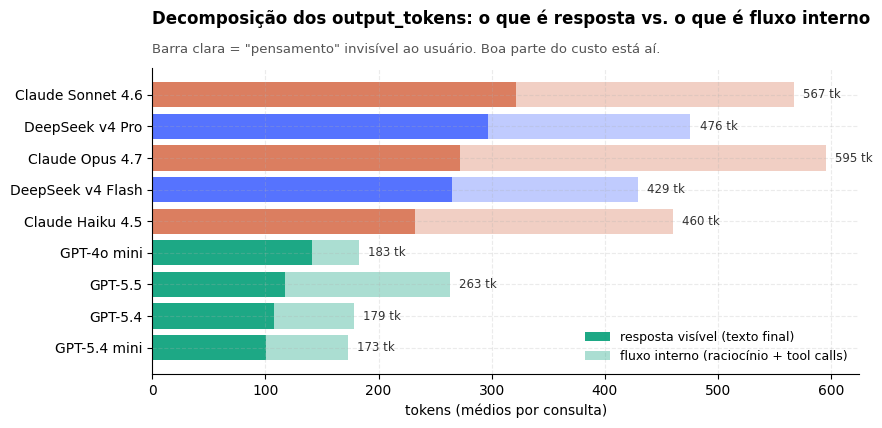

In [2]:
decomp = (fer.groupby('modelo_display')
            .agg(resposta=('resposta_tokens_tiktoken','mean'),
                 fluxo_interno=('tokens_fluxo_interno','mean'))
            .loc[ordem_fer]
            .sort_values('resposta', ascending=True))

cores = [CORES_FAMILIA[FAMILIA[next(k for k,v in MODELO_DISPLAY.items() if v == m)]]
         for m in decomp.index]

fig, ax = plt.subplots(figsize=(9, 4.8))
y = np.arange(len(decomp))

ax.barh(y, decomp['resposta'], color=cores, alpha=0.95, label='resposta visível (texto final)')
ax.barh(y, decomp['fluxo_interno'], left=decomp['resposta'],
        color=cores, alpha=0.35, label='fluxo interno (raciocínio + tool calls)')

for i, (r, f_) in enumerate(zip(decomp['resposta'], decomp['fluxo_interno'])):
    total = r + f_
    ax.text(total + 8, i, f'{total:.0f} tk',
            va='center', fontsize=8.5, color='#333')

ax.set_yticks(y); ax.set_yticklabels(decomp.index)
titulo_acima(ax,
    'Decomposição dos output_tokens: o que é resposta vs. o que é fluxo interno',
    'Barra clara = "pensamento" invisível ao usuário. Boa parte do custo está aí.')
ax.set_xlabel('tokens (médios por consulta)')
ax.legend(loc='lower right')
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

**Conclusão prática.** Para Claude Sonnet 4.6, ~43% dos tokens de saída são pensamento interno. Para a famíliaOpenAI, o overhead é proporcionalmente menor (mas existe). Quando alguém compara "tamanho de resposta" entre modelos, é importante saber se a métrica é `resposta_tokens_tiktoken` (o que o usuário lê) ou `output_tokens` (o que o cliente paga).


## 2. Custo médio por consulta

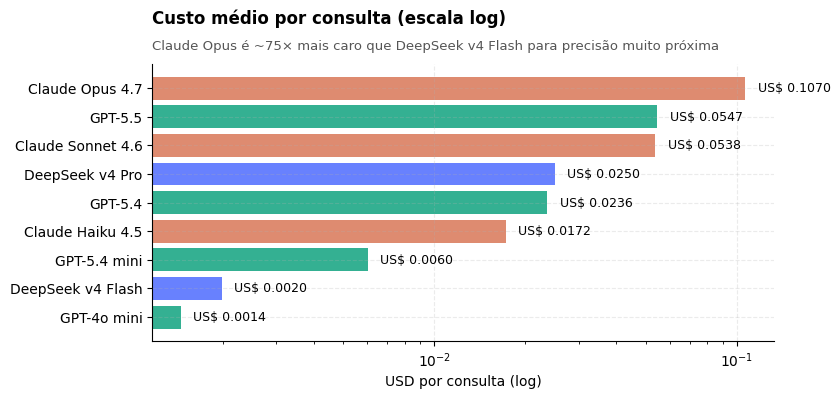

In [3]:
custo = (fer.groupby('modelo_display')['custo_estimado_usd']
           .mean().loc[ordem_fer].sort_values())

cores = [CORES_FAMILIA[FAMILIA[next(k for k,v in MODELO_DISPLAY.items() if v == m)]]
         for m in custo.index]

fig, ax = plt.subplots(figsize=(8.5, 4.5))
y = np.arange(len(custo))
ax.barh(y, custo.values, color=cores, alpha=0.85)
ax.set_yticks(y); ax.set_yticklabels(custo.index)
ax.set_xscale('log')

for i, v in enumerate(custo.values):
    ax.text(v * 1.10, i, f'US$ {v:.4f}', va='center', fontsize=9)

titulo_acima(ax,
    'Custo médio por consulta (escala log)',
    'Claude Opus é ~75× mais caro que DeepSeek v4 Flash para precisão muito próxima')
ax.set_xlabel('USD por consulta (log)')
plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

## 3. Latência e número de invocações

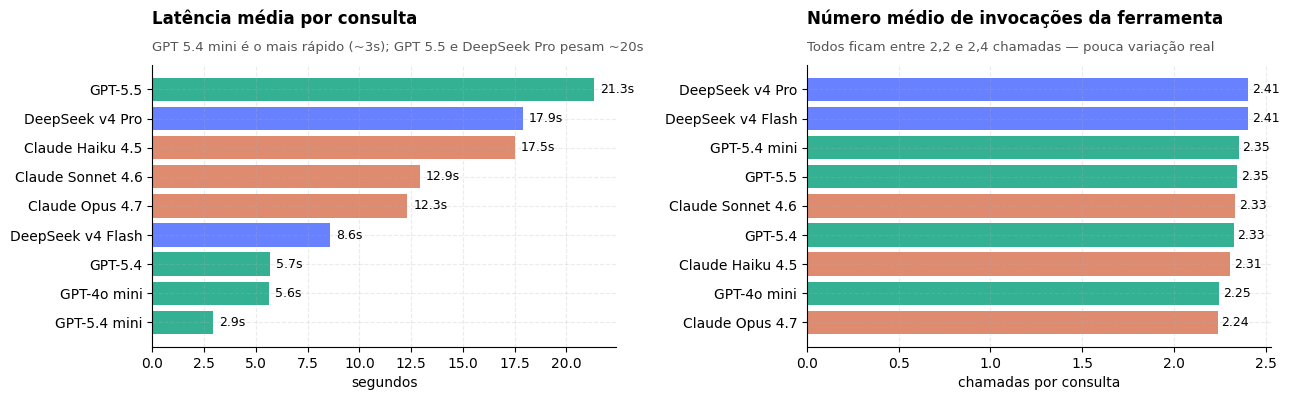

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Latência
lat = (fer.groupby('modelo_display')['latencia_s']
         .mean().loc[ordem_fer].sort_values())
cores = [CORES_FAMILIA[FAMILIA[next(k for k,v in MODELO_DISPLAY.items() if v == m)]]
         for m in lat.index]
y = np.arange(len(lat))
axes[0].barh(y, lat.values, color=cores, alpha=0.85)
axes[0].set_yticks(y); axes[0].set_yticklabels(lat.index)
for i, v in enumerate(lat.values):
    axes[0].text(v + 0.3, i, f'{v:.1f}s', va='center', fontsize=9)
titulo_acima(axes[0],
    'Latência média por consulta',
    'GPT 5.4 mini é o mais rápido (~3s); GPT 5.5 e DeepSeek Pro pesam ~20s')
axes[0].set_xlabel('segundos')

# --- Invocações
inv = (fer.groupby('modelo_display')['n_invocacoes']
         .mean().loc[ordem_fer].sort_values())
cores2 = [CORES_FAMILIA[FAMILIA[next(k for k,v in MODELO_DISPLAY.items() if v == m)]]
          for m in inv.index]
y2 = np.arange(len(inv))
axes[1].barh(y2, inv.values, color=cores2, alpha=0.85)
axes[1].set_yticks(y2); axes[1].set_yticklabels(inv.index)
for i, v in enumerate(inv.values):
    axes[1].text(v + 0.02, i, f'{v:.2f}', va='center', fontsize=9)
titulo_acima(axes[1],
    'Número médio de invocações da ferramenta',
    'Todos ficam entre 2,2 e 2,4 chamadas — pouca variação real')
axes[1].set_xlabel('chamadas por consulta')

plt.tight_layout(rect=[0,0,1,0.93])
plt.show()

**Surpresa do gráfico de invocações:** todos os modelos fazem em média 2,2-2,4 chamadas à ferramenta. Apesar das diferenças enormes em latência (3s a 21s), o número de tool-calls é praticamente idêntico. **A latência não vem do número de chamadas — vem do tempo de raciocínio de cada modelo.** Isso é coerente com a decomposição de tokens da seção 1: modelos como GPT 5.5 e DeepSeek v4 Pro investem em raciocínio mais longo.


## 4. Precisão por dólar e precisão por segundo

Duas formas simples e diretas de combinar qualidade com custo, sem inventar score.


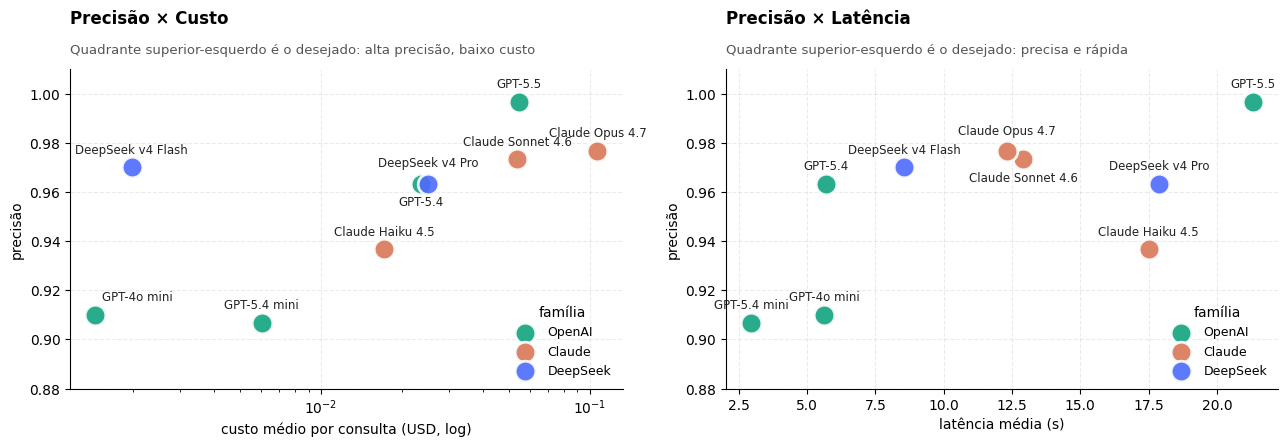

In [5]:
ef = (fer.groupby('modelo_display')
        .agg(precisao=('avaliacao_final','mean'),
             custo=('custo_estimado_usd','mean'),
             latencia=('latencia_s','mean'),
             familia=('familia','first'))
        .loc[ordem_fer])
ef['precisao_por_dolar'] = ef['precisao'] / ef['custo']
ef['precisao_por_segundo'] = ef['precisao'] / ef['latencia']

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# Precisão × custo (scatter)
for fam in CORES_FAMILIA:
    sub = ef[ef['familia']==fam]
    if len(sub):
        axes[0].scatter(sub['custo'], sub['precisao'], s=220,
                        c=CORES_FAMILIA[fam], edgecolor='white', linewidth=2,
                        label=fam, alpha=0.9, zorder=3)
offsets_custo = {
    'GPT-5.4':     (0, -18),
    'DeepSeek v4 Pro': (0,  10),
    'GPT-4o mini': (30, 8),
}
rotulos_em_cima(axes[0], ef['custo'], ef['precisao'], ef.index,
                fontsize=8.5, offsets=offsets_custo)
axes[0].set_xscale('log')
axes[0].set_xlabel('custo médio por consulta (USD, log)')
axes[0].set_ylabel('precisão')
axes[0].set_ylim(0.88, 1.01)
titulo_acima(axes[0],
    'Precisão × Custo',
    'Quadrante superior-esquerdo é o desejado: alta precisão, baixo custo')
axes[0].legend(loc='lower right', title='família')

# Precisão × latência
for fam in CORES_FAMILIA:
    sub = ef[ef['familia']==fam]
    if len(sub):
        axes[1].scatter(sub['latencia'], sub['precisao'], s=220,
                        c=CORES_FAMILIA[fam], edgecolor='white', linewidth=2,
                        label=fam, alpha=0.9, zorder=3)
offsets_lat = {
    'Claude Sonnet 4.6': (0, -18),
    'Claude Opus 4.7':   (0,  10),
}
rotulos_em_cima(axes[1], ef['latencia'], ef['precisao'], ef.index,
                fontsize=8.5, offsets=offsets_lat)
axes[1].set_xlabel('latência média (s)')
axes[1].set_ylabel('precisão')
axes[1].set_ylim(0.88, 1.01)
titulo_acima(axes[1],
    'Precisão × Latência',
    'Quadrante superior-esquerdo é o desejado: precisa e rápida')
axes[1].legend(loc='lower right', title='família')

plt.tight_layout(rect=[0,0,1,0.90])
plt.show()

## 5. Tabela final de eficiência

In [6]:
tabela = ef.copy()
tabela['precisao']             = (tabela['precisao'] * 100).round(1)
tabela['custo']                = tabela['custo'].round(4)
tabela['latencia']             = tabela['latencia'].round(1)
tabela['precisao_por_dolar']   = tabela['precisao_por_dolar'].round(1)
tabela['precisao_por_segundo'] = tabela['precisao_por_segundo'].round(3)
tabela = tabela.sort_values('precisao_por_dolar', ascending=False)
tabela = tabela[['precisao','custo','latencia','precisao_por_dolar','precisao_por_segundo']]
tabela.columns = ['precisão (%)','custo (USD)','latência (s)','precisão/USD','precisão/s']
tabela

,precisão (%),custo (USD),latência (s),precisão/USD,precisão/s
modelo_display,,,,,
GPT-4o mini,91.0,0.0014,5.6,628.5,0.162
DeepSeek v4 Flash,97.0,0.0020,8.6,489.7,0.113
GPT-5.4 mini,90.7,0.0060,2.9,150.4,0.308
Claude Haiku 4.5,93.7,0.0172,17.5,54.4,0.054
GPT-5.4,96.3,0.0236,5.7,40.8,0.169
DeepSeek v4 Pro,96.3,0.0250,17.9,38.5,0.054
GPT-5.5,99.7,0.0547,21.3,18.2,0.047
Claude Sonnet 4.6,97.3,0.0538,12.9,18.1,0.075
Claude Opus 4.7,97.7,0.1070,12.3,9.1,0.079


**O DeepSeek v4 Flash é o "value" do estudo:** entrega 97% de precisão a um custo médio de US$ 0,002 — uma ordem de grandeza mais barato que qualquer Claude. Para uma chamada de ferramenta de uso intenso, é o que dá mais qualidade por dólar.

A síntese consolidada (notebook 05) combina isso com a concisão para chegar à recomendação final.
